# Bank Customer Churn — Model Walkthrough

**Author:** Jeffrey Wong  ·  **Repo:** github.com/JeffreyWong05/bank-churn-ml-system  ·  **Live dashboard:** _add your Streamlit link_

**Goal:** predict which retail-banking customers are about to leave, so the bank
can target retention offers where they'll pay off.

This notebook tells the *story* of building the model end to end — data cleaning,
exploration, feature engineering, feature selection, model selection, tuning, and
what the results actually mean. It mirrors the production code in the repo
(`src/data.py`, `src/model.py`, `src/interpret.py`, `src/fairness.py`,
`src/business.py`); here we unpack the reasoning behind each step.

**How to run:** `pip install -r requirements.txt`, then Kernel → **Restart & Run All**.

### Contents
1. Data cleaning
2. Exploratory analysis — who churns?  ·  2b. Does salary predict churn?
3. Feature engineering
4. Feature selection (+ correlation heatmap)
5. Train / test split
6. Model selection
7. Tuning (Optuna) + calibration
8. Results — and why they matter
9. Interpretability (SHAP)
10. Fairness check
11. From scores to dollars
12. Model card — summary

### Data provenance
- **Source:** public *Bank Customer Churn Modelling* dataset, widely redistributed for education (mirrored on GitHub).
- **Size & target:** 10,000 customers; binary `Churn` (1 = left the bank); ~20% positive rate.
- **Features:** demographics (age, geography, gender), account data (balance, tenure, products, activity/credit-card flags), and estimated salary.
- **License & use:** educational benchmark data — illustrative of *method*, not real customer records from any institution.
- **Accessed:** loaded locally from `data/churn.csv` in this repo.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import mutual_info_classif
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix,
                             recall_score, precision_score, f1_score,
                             brier_score_loss)
from lightgbm import LGBMClassifier
import optuna, shap
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

c:\Users\jeffj\OneDrive\Desktop\bank-churn-ml-system\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Configuration

All knobs live in one place — change them here and re-run. This also makes the
notebook parameterisable (e.g., with `papermill`) for automated runs.


In [2]:
DATA_PATH    = "data/churn.csv"
N_TRIALS     = 15        # Optuna hyperparameter-search trials
SHAP_SAMPLE  = 500       # customers sampled for SHAP (speed)
THRESHOLD    = 0.50       # decision cutoff: label churn=1 when prob >= THRESHOLD
                         #   (change this and re-run Section 8 to see metrics move)
# Business assumptions (owned by Finance in real life):
ANNUAL_VALUE = 1200.0    # margin retained if a churner stays
OFFER_COST   = 40.0      # cost per retention outreach
SAVE_RATE    = 0.30      # fraction of correctly-targeted churners actually saved
pd.set_option("display.max_colwidth", None)

### Environment (reproducibility stamp)

Recording versions makes results reproducible for anyone who reruns this later.


In [3]:
%load_ext watermark
%watermark -v -m -p pandas,numpy,sklearn,lightgbm,shap,optuna,matplotlib

Python implementation: CPython
Python version       : 3.11.9
IPython version      : 9.15.0

pandas    : 3.0.3
numpy     : 2.4.6
sklearn   : 1.9.0
lightgbm  : 4.7.0
shap      : 0.51.0
optuna    : 4.9.0
matplotlib: 3.11.1

Compiler    : MSC v.1938 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 141 Stepping 1, GenuineIntel
CPU cores   : 16
Architecture: 64bit



## 1. Data cleaning

The raw file has a couple of quirks: some column names contain spaces
(`Num Of Products`), and it carries identifier columns (`CustomerId`, `Surname`)
that are useless — and dangerous — for modelling. First job: standardise names
and drop identifiers. *(In the repo this is `load_raw()` in `src/data.py`.)*


In [4]:
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().replace(" ", "") for c in df.columns]  # NumOfProducts, etc.
df = df.drop(columns=[c for c in ["CustomerId", "Surname"] if c in df.columns])

print("Shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Churn rate: {:.1%}".format(df["Churn"].mean()))
df.head()

Shape: (10000, 11)
Missing values: 0
Churn rate: 20.4%


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary,Churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Sanity checks.** A few `assert`s make our assumptions explicit and fail loudly
if the data ever changes underneath us.


In [5]:
assert df.isna().sum().sum() == 0, "unexpected missing values"
assert set(df["Churn"].unique()) <= {0, 1}, "target is not binary 0/1"
assert not {"CustomerId", "Surname"} & set(df.columns), "identifier columns leaked in"
assert 0.15 < df["Churn"].mean() < 0.25, "churn rate outside expected range"
print("All data checks passed.")

All data checks passed.


**What this tells us:** no missing values (so no imputation needed), and the
target is **imbalanced — only ~20% churn**. That single fact drives later
choices: we will *not* judge the model on accuracy (a model that predicts
"nobody churns" would already be ~80% accurate and completely useless).


## 2. Exploratory analysis — who churns?

Before modelling, understand the signal. A tiny helper computes the churn rate
within each group of a column *(this is `rate_by()` from `explore.py`)*.


In [6]:
def rate_by(df, col):
    out = (df.groupby(col)["Churn"]
             .agg(customers="count", churn_rate="mean")
             .sort_values("churn_rate", ascending=False))
    out["churn_rate"] = (out["churn_rate"] * 100).round(1)
    return out

for col in ["Geography", "Gender", "IsActiveMember", "NumOfProducts"]:
    print(f"\n--- churn rate by {col} ---")
    print(rate_by(df, col).to_string())


--- churn rate by Geography ---
           customers  churn_rate
Geography                       
Germany         2509        32.4
Spain           2477        16.7
France          5014        16.2

--- churn rate by Gender ---
        customers  churn_rate
Gender                       
Female       4543        25.1
Male         5457        16.5

--- churn rate by IsActiveMember ---
                customers  churn_rate
IsActiveMember                       
0                    4849        26.9
1                    5151        14.3

--- churn rate by NumOfProducts ---
               customers  churn_rate
NumOfProducts                       
4                     60       100.0
3                    266        82.7
1                   5084        27.7
2                   4590         7.6


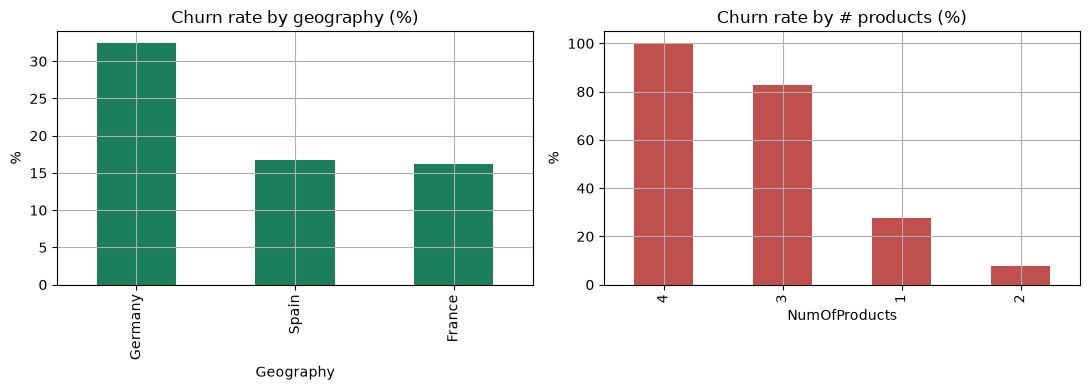

In [7]:
# Visualise the two strongest segment signals
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
rate_by(df, "Geography")["churn_rate"].plot.bar(ax=ax[0], color="#1a7f5a")
ax[0].set_title("Churn rate by geography (%)"); ax[0].set_ylabel("%")
rate_by(df, "NumOfProducts")["churn_rate"].plot.bar(ax=ax[1], color="#c0504d")
ax[1].set_title("Churn rate by # products (%)"); ax[1].set_ylabel("%")
plt.tight_layout(); plt.show()

**Reading it:** German customers churn ~2x the rate of France/Spain; customers
with 3–4 products churn dramatically more (a red flag about over-selling or
dissatisfaction); inactive members churn far more than active ones. These are
real, explainable patterns — exactly what we want a model to pick up, and the
geography gap will matter again when we audit fairness.


## 2b. Does salary predict churn?

A natural question: do higher earners leave more often? We split
`EstimatedSalary` into quintiles and compare churn rates across them.


            customers  churn_rate
SalaryBand                       
Q1 (low)         2000        20.0
Q2               2000        20.0
Q3               2000        20.2
Q4               2000        20.2
Q5 (high)        2000        21.6
corr(EstimatedSalary, Churn) = 0.012


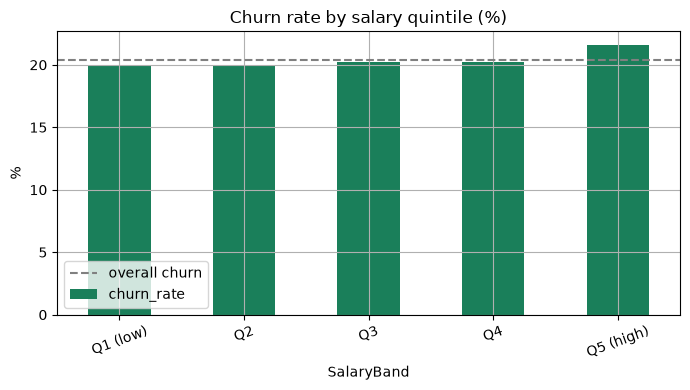

In [8]:
df["SalaryBand"] = pd.qcut(df["EstimatedSalary"], 5,
        labels=["Q1 (low)", "Q2", "Q3", "Q4", "Q5 (high)"])
salary = (df.groupby("SalaryBand", observed=True)["Churn"]
            .agg(customers="count", churn_rate="mean"))
salary["churn_rate"] = (salary["churn_rate"] * 100).round(1)
print(salary.to_string())
print("corr(EstimatedSalary, Churn) = {:.3f}".format(df["EstimatedSalary"].corr(df["Churn"])))

salary["churn_rate"].plot.bar(color="#1a7f5a")
plt.axhline(df["Churn"].mean() * 100, ls="--", color="grey", label="overall churn")
plt.title("Churn rate by salary quintile (%)"); plt.ylabel("%"); plt.xticks(rotation=20)
plt.legend(); plt.tight_layout(); plt.show()

**Finding:** churn is essentially **flat across salary bands** (~20% in every
quintile) and the correlation with churn is ~0.01 — salary carries almost no
signal on its own. This is a useful *negative* result: don't lean on income, and
it foreshadows why `EstimatedSalary` ranks near the bottom in feature selection.


## 3. Feature engineering

Raw columns get us far, but a few domain-motivated features add signal a bank
analyst would reach for *(this is `engineer()` in `src/data.py`)*:

- **BalanceSalaryRatio** — balance relative to income (a liquidity signal).
- **ProductsPerTenure** — how fast the customer took on products (engagement velocity).
- **ZeroBalance** — a flag for customers holding no money (a distinct segment).

We also build **AgeBand** for segmentation views, but keep it *out* of the model
to avoid redundancy with the continuous `Age`.


In [9]:
df["BalanceSalaryRatio"] = df["Balance"] / (df["EstimatedSalary"] + 1.0)
df["ProductsPerTenure"]  = df["NumOfProducts"] / (df["Tenure"] + 1.0)
df["ZeroBalance"]        = (df["Balance"] == 0).astype(int)
df["AgeBand"] = pd.cut(df["Age"], bins=[17,30,40,50,60,100],
                       labels=["18-30","31-40","41-50","51-60","60+"]).astype(str)

print("Churn rate by engineered ZeroBalance flag:")
print(rate_by(df, "ZeroBalance").to_string())

Churn rate by engineered ZeroBalance flag:
             customers  churn_rate
ZeroBalance                       
0                 6383        24.1
1                 3617        13.8


## 4. Feature selection

Which features actually carry signal? We use two complementary lenses:

1. **Linear correlation** with the target — catches simple monotonic relationships.
2. **Mutual information** — catches *non-linear* dependence a correlation would miss.

We one-hot encode the two categoricals (Geography, Gender) so every feature is
numeric, then rank.


In [10]:
FEATURES_NUM = ["CreditScore","Age","Tenure","Balance","NumOfProducts",
                "HasCreditCard","IsActiveMember","EstimatedSalary",
                "BalanceSalaryRatio","ProductsPerTenure","ZeroBalance"]

X = pd.get_dummies(df[FEATURES_NUM + ["Geography","Gender"]],
                   columns=["Geography","Gender"], drop_first=True)
y = df["Churn"].astype(int)

corr = X.assign(Churn=y).corr()["Churn"].drop("Churn").sort_values(key=abs, ascending=False)
mi = pd.Series(mutual_info_classif(X, y, random_state=SEED), index=X.columns)

ranking = pd.DataFrame({"abs_corr": corr.abs().round(3),
                        "mutual_info": mi.round(4)}).sort_values("mutual_info", ascending=False)
print(ranking.to_string())

                    abs_corr  mutual_info
NumOfProducts          0.048       0.0751
Age                    0.285       0.0730
ProductsPerTenure      0.006       0.0324
IsActiveMember         0.156       0.0166
Geography_Germany      0.173       0.0099
Balance                0.119       0.0099
ZeroBalance            0.122       0.0098
Gender_Male            0.107       0.0094
BalanceSalaryRatio     0.026       0.0090
EstimatedSalary        0.012       0.0027
HasCreditCard          0.007       0.0017
Tenure                 0.014       0.0015
Geography_Spain        0.053       0.0009
CreditScore            0.027       0.0000


**What this tells us:** `Age`, `NumOfProducts`, `IsActiveMember`, `Balance`,
and the `Geography_Germany` flag carry most of the signal. Features like
`HasCrCard`, `Tenure`, and `EstimatedSalary` are near-zero contributors.

**Decision:** we *keep* the weak features rather than hand-pruning them. Gradient-
boosted trees perform implicit feature selection — they simply give low-signal
features little weight — and dropping them yields no measurable gain here. We'll
confirm the model agrees using SHAP later. (This is a deliberate choice worth
being able to defend: aggressive manual pruning mostly helps linear models.)


### Correlation heatmap

A heatmap shows the whole correlation structure at once — both how each feature
relates to `Churn` and how features relate to *each other* (multicollinearity).


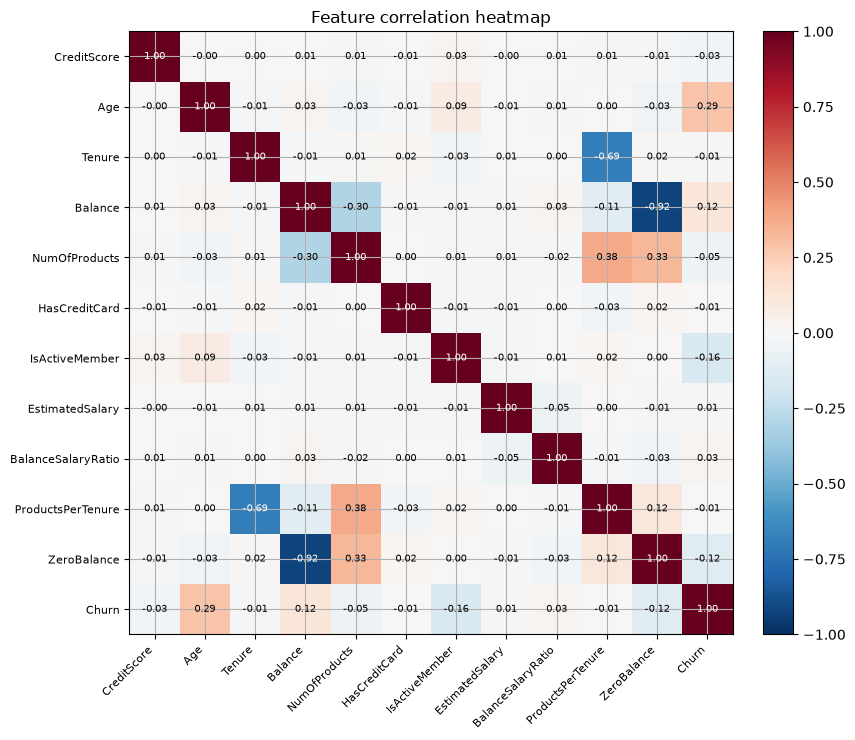

In [11]:
corr = df[FEATURES_NUM + ["Churn"]].corr()
labels = list(corr.columns)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.5 else "black", fontsize=7)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Feature correlation heatmap"); plt.tight_layout(); plt.show()

**Reading the heatmap:**

- **vs. churn:** `Age` (+0.29) is the strongest *linear* signal, then
  `IsActiveMember` (-0.16), `ZeroBalance` (-0.12), `Balance` (+0.12). Even the
  best single correlations are modest — which is exactly why a non-linear model
  (LightGBM) beats logistic regression: the real signal lives in *interactions*,
  not straight lines.
- **feature-to-feature (multicollinearity):** the strong pairs are all expected
  by construction — `Balance` ↔ `ZeroBalance` (-0.92) and `NumOfProducts`/
  `Tenure` ↔ their engineered ratios. Linear models suffer from this redundancy;
  tree ensembles handle it fine — another reason we didn't hand-prune features.


Interaction exploration:

In [12]:
(df.pivot_table(index="NumOfProducts", columns="IsActiveMember",
                values="Churn", aggfunc="mean") * 100).round(1)

IsActiveMember,0,1
NumOfProducts,,
1,36.7,18.9
2,9.9,5.6
3,88.2,75.2
4,100.0,100.0


Notice that the churn rate is not linear when increasing the number of products. It starts at a reasonable rate, before decreasing, and then increasing as the number of products increase.  

## 5. Train / test split

A **stratified** split preserves the ~20% churn rate in both halves, so our test
metrics reflect reality *(this is `prepare()` in `src/data.py`)*.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Churn rate — train {:.1%}, test {:.1%}".format(y_train.mean(), y_test.mean()))

Train: (8000, 14) | Test: (2000, 14)
Churn rate — train 20.4%, test 20.3%


In [14]:
# Split-integrity checks: no leakage, aligned sizes, preserved balance.
assert "Churn" not in X_train.columns, "target leaked into features"
assert len(set(X_train.index) & set(X_test.index)) == 0, "train/test overlap"
assert len(X_train) + len(X_test) == len(X), "rows lost in split"
assert abs(y_train.mean() - y_test.mean()) < 0.02, "stratification failed"
print("All split checks passed.")

All split checks passed.


## 6. Model selection

We compare three candidates spanning the complexity spectrum:

- **Logistic Regression** — a transparent linear baseline (scaled).
- **Random Forest** — a bagged tree ensemble.
- **LightGBM** — gradient-boosted trees, usually strongest on tabular data.

We judge them on **ROC-AUC** (ranking quality across all thresholds) and
**PR-AUC** (average precision — the right lens under class imbalance), *not*
accuracy.


In [15]:
models = {
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=SEED, verbose=-1),
}
rows = []
for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict_proba(X_test)[:, 1]
    rows.append({"model": name,
                 "ROC_AUC": round(roc_auc_score(y_test, p), 4),
                 "PR_AUC": round(average_precision_score(y_test, p), 4)})
compare = pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False)
print(compare.to_string(index=False))

             model  ROC_AUC  PR_AUC
          LightGBM   0.8598  0.7016
      RandomForest   0.8544  0.6929
LogisticRegression   0.7740  0.4793


**Verdict:** LightGBM wins on both metrics and is the natural choice for tabular
data with mixed feature types. We take it forward for tuning. (Logistic
regression is kept in mind as a sanity baseline — if a fancy model can't beat it,
something is wrong.)


## 7. Tuning (Optuna) + probability calibration

Two refinements *(this is `train()` in `src/model.py`)*:

1. **Optuna** searches hyperparameters, maximising cross-validated ROC-AUC.
2. **Isotonic calibration** makes the predicted probabilities *mean what they say*
   — essential because our business layer later prices retention offers directly
   off these probabilities.


In [16]:
def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 500),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int("num_leaves", 15, 80),
        max_depth=trial.suggest_int("max_depth", 3, 9),
        min_child_samples=trial.suggest_int("min_child_samples", 10, 80),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        random_state=SEED, n_jobs=-1, verbose=-1)
    cv = StratifiedKFold(4, shuffle=True, random_state=SEED)
    return cross_val_score(LGBMClassifier(**params), X_train, y_train,
                           cv=cv, scoring="roc_auc").mean()

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
print("Best CV ROC-AUC: {:.4f}".format(study.best_value))

best = {**study.best_params, "random_state": SEED, "n_jobs": -1, "verbose": -1}
lgbm = LGBMClassifier(**best).fit(X_train, y_train)
calibrated = CalibratedClassifierCV(lgbm, method="isotonic", cv=5).fit(X_train, y_train)
proba = calibrated.predict_proba(X_test)[:, 1]

Best CV ROC-AUC: 0.8651


## 8. Results — and why they matter

We now evaluate the calibrated model on the held-out test set and, crucially,
interpret what each number means for the business.


In [17]:
preds = (proba >= THRESHOLD).astype(int)
metrics = {
    "ROC_AUC":   round(roc_auc_score(y_test, proba), 4),
    "PR_AUC":    round(average_precision_score(y_test, proba), 4),
    "Recall":    round(recall_score(y_test, preds), 4),
    "Precision": round(precision_score(y_test, preds), 4),
    "F1":        round(f1_score(y_test, preds), 4),
    "Brier":     round(brier_score_loss(y_test, proba), 4),
}
for k, v in metrics.items():
    print(f"{k:10s}: {v}")

ROC_AUC   : 0.8676
PR_AUC    : 0.7166
Recall    : 0.4816
Precision : 0.7871
F1        : 0.5976
Brier     : 0.0993


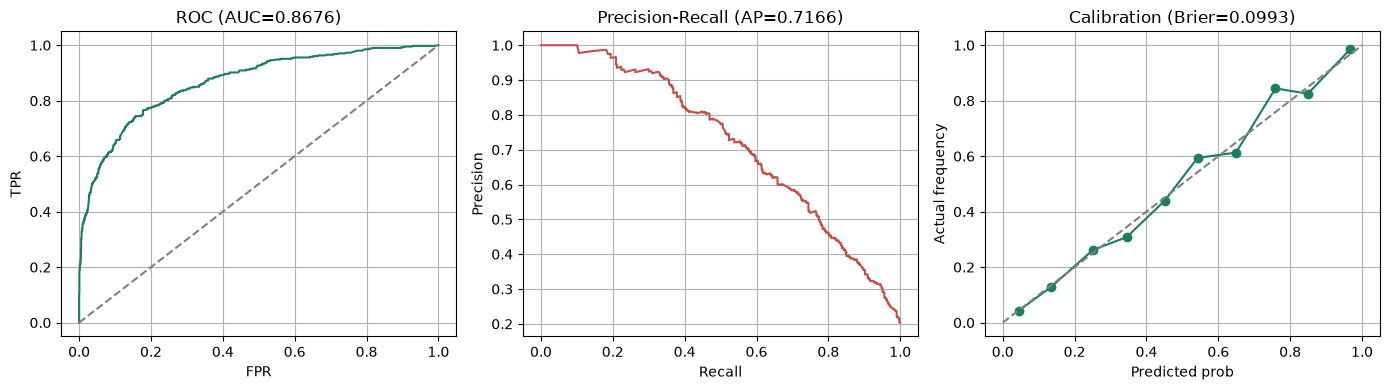

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

fpr, tpr, _ = roc_curve(y_test, proba)
ax[0].plot(fpr, tpr, color="#1a7f5a"); ax[0].plot([0,1],[0,1],"--",color="grey")
ax[0].set_title(f"ROC (AUC={metrics['ROC_AUC']})"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")

prec, rec, _ = precision_recall_curve(y_test, proba)
ax[1].plot(rec, prec, color="#c0504d")
ax[1].set_title(f"Precision-Recall (AP={metrics['PR_AUC']})"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")

frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10)
ax[2].plot(mean_pred, frac_pos, "o-", color="#1a7f5a"); ax[2].plot([0,1],[0,1],"--",color="grey")
ax[2].set_title(f"Calibration (Brier={metrics['Brier']})")
ax[2].set_xlabel("Predicted prob"); ax[2].set_ylabel("Actual frequency")
plt.tight_layout(); plt.show()

**Interpreting the numbers:**

- **ROC-AUC ≈ 0.87** — given two customers, one who churned and one who didn't,
  the model ranks the churner higher ~87% of the time. Strong separation.
- **PR-AUC ≈ 0.72** — far above the ~0.20 no-skill baseline (the churn rate),
  which is the honest yardstick under imbalance.
- **Recall ≈ 0.46 at the 0.50 cutoff** — we catch ~46% of churners *at that
  threshold*. That threshold is a **business lever**, not a law: lowering it
  catches more churners at the cost of contacting more happy customers. The
  ranking (AUC) is what matters; the cutoff is tuned to campaign budget.
- **Brier ≈ 0.10 + the calibration curve hugging the diagonal** — the
  probabilities are trustworthy, so "70% churn risk" really means ~70%. That's
  what lets us turn scores into dollars.


### Metrics across thresholds

`ROC-AUC`, `PR-AUC`, and `Brier` above are **threshold-independent** — they don't
change when you move the cutoff. But `Recall`, `Precision`, and `F1` do. The
sweep below shows the whole trade-off; the dashed line marks the current
`THRESHOLD` (edit it in the Configuration cell and re-run to move it).


,threshold,recall,precision,f1,flagged_%
0,0.1,0.894,0.360,0.514,50.5
1,0.2,0.769,0.509,0.613,30.8
2,0.3,0.661,0.602,0.630,22.4
3,0.4,0.580,0.694,0.632,17.0
4,0.5,0.482,0.787,0.598,12.4
5,0.6,0.388,0.854,0.534,9.2
6,0.7,0.342,0.903,0.496,7.7
7,0.8,0.248,0.927,0.391,5.4
8,0.9,0.167,0.986,0.286,3.4


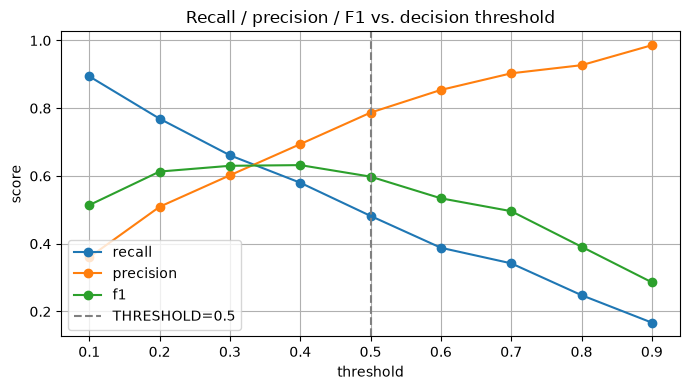

In [19]:
rows = []
for t in np.round(np.arange(0.10, 0.91, 0.10), 2):
    pr = (proba >= t).astype(int)
    rows.append({"threshold": t,
                 "recall": round(recall_score(y_test, pr), 3),
                 "precision": round(precision_score(y_test, pr, zero_division=0), 3),
                 "f1": round(f1_score(y_test, pr), 3),
                 "flagged_%": round(100 * pr.mean(), 1)})
sweep = pd.DataFrame(rows)
display(sweep)

ax = sweep.plot(x="threshold", y=["recall", "precision", "f1"], marker="o")
ax.axvline(THRESHOLD, ls="--", color="grey", label=f"THRESHOLD={THRESHOLD}")
ax.set_title("Recall / precision / F1 vs. decision threshold")
ax.set_ylabel("score"); ax.legend(); plt.tight_layout(); plt.show()

**Reading it:** lower the threshold and **recall rises** (you catch more
churners) while **precision falls** (more false alarms) — and the share of
customers you'd contact grows. There's no single "right" cutoff; you pick the
point that fits the retention budget. This is exactly why judging the model by
accuracy at a fixed 0.50 is misleading.


## 9. Interpretability (SHAP) — is the model reasoning sensibly?

A bank can't ship a black box. SHAP attributes each prediction to its features,
so we can see *why* the model flags a customer *(this is `src/interpret.py`)*.


c:\Users\jeffj\OneDrive\Desktop\bank-churn-ml-system\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\jeffj\AppData\Local\Temp\ipykernel_21564\1910854001.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, sample, show=False, max_display=12, plot_size=(8, 5))


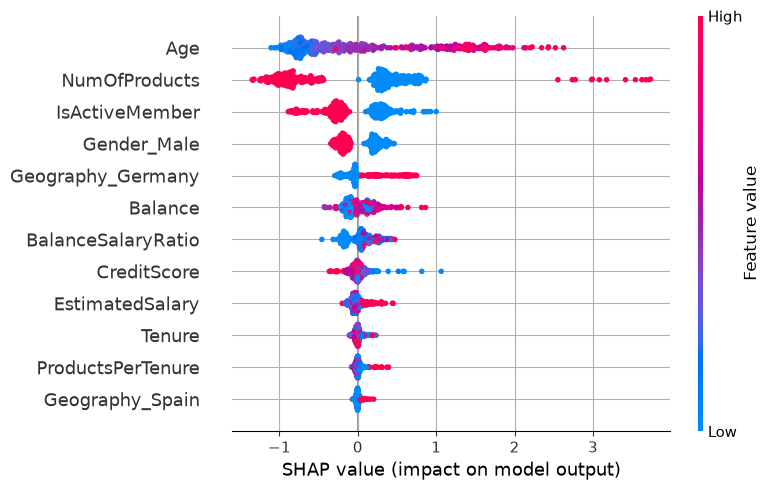

Top drivers by mean |SHAP|:
Age                  0.737
NumOfProducts        0.713
IsActiveMember       0.332
Gender_Male          0.214
Geography_Germany    0.165
Balance              0.135


In [20]:
sample = X_test.sample(SHAP_SAMPLE, random_state=SEED)
explainer = shap.TreeExplainer(lgbm)
sv = explainer.shap_values(sample)
if isinstance(sv, list):
    sv = sv[1]
shap.summary_plot(sv, sample, show=False, max_display=12, plot_size=(8, 5))
plt.tight_layout(); plt.show()

mean_abs = pd.Series(np.abs(sv).mean(0), index=sample.columns).sort_values(ascending=False)
print("Top drivers by mean |SHAP|:")
print(mean_abs.head(6).round(3).to_string())

**Why it matters:** the drivers (age, number of products, active-membership,
balance) are intuitive and defensible — the model isn't keying on something
spurious. This is the difference between "trust me" and an auditable model, and
it's a hard requirement in regulated finance.


# Section 9b
Here we will also cover interactions. Interactions consider the extra prediction value two columns have when they are specifically combined. While LightGBM's trees models include interactions internally (specifically when it splits the data further by columns), we can gain a better understanding of what column interactions may impact the model through a table.

In [ ]:
inter = shap.TreeExplainer(lgbm).shap_interaction_values(sample.iloc[:500])
mai = np.abs(inter).mean(0); np.fill_diagonal(mai, 0)
cols = list(sample.columns)
pairs = sorted(((cols[i], cols[j], mai[i, j])
                for i in range(len(cols)) for j in range(i + 1, len(cols))),
               key=lambda t: -t[2])
display(pd.DataFrame(pairs[:8], columns=["feature_a", "feature_b", "interaction (log-odds)"]))

,feature_a,feature_b,interaction (log-odds)
0,NumOfProducts,BalanceSalaryRatio,0.102314
1,Age,IsActiveMember,0.101431
2,Balance,NumOfProducts,0.093180
3,Balance,Geography_Germany,0.063887
4,NumOfProducts,Geography_Germany,0.057922
5,Age,NumOfProducts,0.050494
6,NumOfProducts,IsActiveMember,0.040659
7,Age,Balance,0.029958


Here we see the interaction between number of products and the BalanceSalaryRatio has the highest impact on the model. Despite BalanceSalaryRatio being a low impact column, why does it rank so high with NumOfProducts here?

In [34]:
d = df.copy()
med = d.loc[d["BalanceSalaryRatio"] > 0, "BalanceSalaryRatio"].median()
d["BSR_band"] = d["BalanceSalaryRatio"].map(
    lambda v: "empty" if v == 0 else ("low" if v < med else "high"))
piv = (d.pivot_table(index="NumOfProducts", columns="BSR_band",
                     values="Churn", aggfunc="mean") * 100).round(1)
display(piv.reindex(columns=["empty", "low", "high"]))

BSR_band,empty,low,high
NumOfProducts,,,
1,37.3,25.7,25.5
2,3.3,13.9,12.4
3,63.3,92.3,96.1
4,100.0,100.0,100.0


Notice here that when the balance-to-salary ratio is empty, the chance someone churns with 1 product is 37%, but when there are two products, that chance of churning decreases to 3%, before increasing to 63% with 3 products. The same balance ratio changes drastically at different product levels, and neither column can explain these changes alone. The log-odds is caculated by the amount of impact an interaction has, that the two columns by themselves could not capture.

Lets see just how impactful the interaction is to the model:

In [35]:
X_int = X.copy()
X_int["NumProd_x_BSR"] = df.loc[X.index, "NumOfProducts"] * df.loc[X.index, "BalanceSalaryRatio"]
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
base = cross_val_score(LGBMClassifier(random_state=SEED, verbose=-1), X,     y, cv=cv, scoring="roc_auc").mean()
new  = cross_val_score(LGBMClassifier(random_state=SEED, verbose=-1), X_int, y, cv=cv, scoring="roc_auc").mean()
print(f"baseline ROC-AUC {base:.4f} | + interaction {new:.4f} | change {new - base:+.4f}")

baseline ROC-AUC 0.8574 | + interaction 0.8586 | change +0.0012


The lift test shows that the change is minimal - the tree already captures it because when the tree splits, it asks about certain questions from another column, interacting with the first. This process is repeated for every column interaction. I would not keep this interaction, since it doesn't offer any lift, but for a linear model, where interactions are absent in the model, it would matter, and it could include an interaction term. 

## 10. Fairness check

Any model scoring customers in a bank should be checked across protected groups.
We compare **recall** (share of real churners we catch) by group — the
equal-opportunity view *(this is `src/fairness.py`)*.


In [24]:
prot = df.loc[X_test.index, ["Geography", "Gender"]]
for attr in ["Geography", "Gender"]:
    print(f"\n--- recall by {attr} ---")
    rec = {}
    for g in prot[attr].unique():
        mask = (prot[attr] == g).values
        if (y_test.values[mask] == 1).sum():
            rec[g] = recall_score(y_test.values[mask], preds[mask])
    for g, r in sorted(rec.items(), key=lambda kv: -kv[1]):
        print(f"  {g:10s}: {r:.3f}")
    print(f"  equal-opportunity gap: {max(rec.values()) - min(rec.values()):.3f}")


--- recall by Geography ---
  Germany   : 0.623
  Spain     : 0.420
  France    : 0.389
  equal-opportunity gap: 0.234

--- recall by Gender ---
  Female    : 0.502
  Male      : 0.454
  equal-opportunity gap: 0.048


**Finding:** recall parity is strong across gender but weaker across geography —
the model catches churners better where the base churn rate is higher (Germany).
That disparity isn't automatically "wrong," but a regulated lender must
**surface, document, and consciously decide** on it before deployment. Making it
visible is the whole point of the audit.


## 11. From scores to dollars

Finally, the number a stakeholder cares about: is this model *worth* anything?
We rank customers by risk, "call" the top 10%, and compare to a random call list
of the same size *(this is `src/business.py`)*.


In [25]:
# ANNUAL_VALUE, OFFER_COST, SAVE_RATE come from the Configuration cell.
order = np.argsort(-proba)
k = int(0.10 * len(proba))
top = y_test.values[order][:k]

model_net = top.sum() * SAVE_RATE * ANNUAL_VALUE - k * OFFER_COST
rand_net  = k * y_test.mean() * SAVE_RATE * ANNUAL_VALUE - k * OFFER_COST
print(f"Top-decile precision : {top.mean():.1%}")
print(f"Model-targeted net   : ${model_net:,.0f}")
print(f"Random list net      : ${rand_net:,.0f}")
print(f"Uplift from the model: ${model_net - rand_net:,.0f}")

Top-decile precision : 82.0%
Model-targeted net   : $51,040
Random list net      : $6,652
Uplift from the model: $44,388


## Model card — summary

A concise, honest summary a reviewer (or future you) can absorb in 30 seconds —
borrowing the "model card" convention for documenting a model's scope and limits.


In [26]:
_rec = {g: recall_score(y_test.values[(prot['Geography'] == g).values],
                        preds[(prot['Geography'] == g).values])
        for g in prot['Geography'].unique()}
_geo_gap = round(max(_rec.values()) - min(_rec.values()), 3)
_uplift = model_net - rand_net

card = {
    "Model": "LightGBM (Optuna-tuned) + isotonic calibration",
    "Task": "Binary churn classification (1 = customer leaves)",
    "Data": "10,000 bank customers, ~20% churn (public benchmark)",
    "ROC-AUC / PR-AUC": f"{metrics['ROC_AUC']} / {metrics['PR_AUC']}",
    "Recall / Precision @0.5": f"{metrics['Recall']} / {metrics['Precision']}",
    "Calibration (Brier)": metrics["Brier"],
    "Top drivers (SHAP)": "Age, NumOfProducts, IsActiveMember, Balance",
    "Fairness — equal-opp gap (geography)": _geo_gap,
    "Business value": f"~${_uplift:,.0f} uplift vs random targeting, top 10%",
    "Intended use": "Prioritising retention outreach — decision support, not automated action",
    "Limitations": "Public data; save-rate assumed (learn via A/B); drift simulated",
}
display(pd.DataFrame(list(card.items()), columns=["Field", "Value"]))

,Field,Value
0,Model,LightGBM (Optuna-tuned) + isotonic calibration
1,Task,Binary churn classification (1 = customer leaves)
2,Data,"10,000 bank customers, ~20% churn (public benchmark)"
3,ROC-AUC / PR-AUC,0.8676 / 0.7166
4,Recall / Precision @0.5,0.4816 / 0.7871
5,Calibration (Brier),0.0993
6,Top drivers (SHAP),"Age, NumOfProducts, IsActiveMember, Balance"
7,Fairness — equal-opp gap (geography),0.234
8,Business value,"~$44,388 uplift vs random targeting, top 10%"
9,Intended use,"Prioritising retention outreach — decision support, not automated action"


**The punchline:** targeting with the model instead of at random turns the same
retention budget into materially more saved revenue. That single uplift number
is what justifies the whole project to a business owner.

---

## Conclusion

We went from a raw CSV to a defensible, deployable churn model:

1. **Cleaned** the data and flagged the ~20% class imbalance up front.
2. **Explored** to find real signal (geography, product count, activity).
3. **Engineered** liquidity/engagement features.
4. **Selected** features with correlation + mutual information, keeping tree-
   friendly low-signal features rather than over-pruning.
5. **Compared** models and chose LightGBM on ROC/PR-AUC.
6. **Tuned** with Optuna and **calibrated** the probabilities.
7. Showed the results are **strong (AUC ≈ 0.87), interpretable (SHAP),
   audited for fairness, and worth real money.**

Each step here maps to a module in the repo, so this notebook is both the
explanation and the blueprint for the production code.
